# Setup

In [1]:
from pathlib import Path
import ast
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

from thesis_assyrian_relief.utils.inspection import (
    plot_relief_views,
    plot_query_and_retrieved_reliefs,
)

In [5]:
IMAGE_LEVEL_CSV = "../data/splits/image_level_dataset_v2.csv"
IMAGE_ROOT = "/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2"
FAILURES_CSV = "../outputs/retrieval/test_failures_v2.csv"

df_failures = pd.read_csv(FAILURES_CSV)
print(df_failures.shape)
df_failures.head()

(8, 8)


,query_relief_id,query_authority,topk_reliefs,topk_labels,topk_sims,top1_correct,top3_hit,top5_hit
0,AO 19852,Tiglath-Pileser III,"['BM 124928', 'BM 124569', 'BM 124931', 'BM 124867', 'BM 124869']","['Ashurbanipal', 'Ashurnasirpal II', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal']","[0.8097933530807495, 0.7212860584259033, 0.6826981902122498, 0.636707067489624, 0.5879935026168823]",False,False,False
1,BM 118908,Tiglath-Pileser III,"['BM 124569', 'BM 124928', 'BM 124537', 'BM 124575', 'BRK 55.150']","['Ashurnasirpal II', 'Ashurbanipal', 'Ashurnasirpal II', 'Ashurnasirpal II', 'Ashurnasirpal II']","[0.7887091636657715, 0.771141767501831, 0.7387610673904419, 0.7181183695793152, 0.713362991809845]",False,False,False
2,BM 118914,Ashurbanipal,"['BM 124569', 'BM 124537', 'BRK 55.150', 'BM 124575', 'BM 124928']","['Ashurnasirpal II', 'Ashurnasirpal II', 'Ashurnasirpal II', 'Ashurnasirpal II', 'Ashurbanipal']","[0.9110638499259949, 0.8523273468017578, 0.8494089245796204, 0.8483099937438965, 0.8414375185966492]",False,False,True
3,BM 118931,Tiglath-Pileser III,"['BM 124938', 'BM 124888', 'BM 124933', 'BM 124794', 'BM 124857']","['Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal']","[0.7830532789230347, 0.741011381149292, 0.7387780547142029, 0.730103611946106, 0.725326418876648]",False,False,False
4,BM 124900,Sennacherib,"['BM 124918', 'BM 136774', 'BM 124872', 'AO 19902', 'BM 124869']","['Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal']","[0.42579197883605957, 0.42361360788345337, 0.4200250506401062, 0.4127442240715027, 0.4080331325531006]",False,False,False


# show the failure table compactly

In [6]:
cols = [
    "query_relief_id",
    "query_authority",
    "topk_reliefs",
    "topk_labels",
    "topk_sims",
    "top1_correct",
    "top3_hit",
    "top5_hit",
]

df_failures[cols]

,query_relief_id,query_authority,topk_reliefs,topk_labels,topk_sims,top1_correct,top3_hit,top5_hit
0,AO 19852,Tiglath-Pileser III,"['BM 124928', 'BM 124569', 'BM 124931', 'BM 124867', 'BM 124869']","['Ashurbanipal', 'Ashurnasirpal II', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal']","[0.8097933530807495, 0.7212860584259033, 0.6826981902122498, 0.636707067489624, 0.5879935026168823]",False,False,False
1,BM 118908,Tiglath-Pileser III,"['BM 124569', 'BM 124928', 'BM 124537', 'BM 124575', 'BRK 55.150']","['Ashurnasirpal II', 'Ashurbanipal', 'Ashurnasirpal II', 'Ashurnasirpal II', 'Ashurnasirpal II']","[0.7887091636657715, 0.771141767501831, 0.7387610673904419, 0.7181183695793152, 0.713362991809845]",False,False,False
2,BM 118914,Ashurbanipal,"['BM 124569', 'BM 124537', 'BRK 55.150', 'BM 124575', 'BM 124928']","['Ashurnasirpal II', 'Ashurnasirpal II', 'Ashurnasirpal II', 'Ashurnasirpal II', 'Ashurbanipal']","[0.9110638499259949, 0.8523273468017578, 0.8494089245796204, 0.8483099937438965, 0.8414375185966492]",False,False,True
3,BM 118931,Tiglath-Pileser III,"['BM 124938', 'BM 124888', 'BM 124933', 'BM 124794', 'BM 124857']","['Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal']","[0.7830532789230347, 0.741011381149292, 0.7387780547142029, 0.730103611946106, 0.725326418876648]",False,False,False
4,BM 124900,Sennacherib,"['BM 124918', 'BM 136774', 'BM 124872', 'AO 19902', 'BM 124869']","['Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal']","[0.42579197883605957, 0.42361360788345337, 0.4200250506401062, 0.4127442240715027, 0.4080331325531006]",False,False,False
5,MET 17.190.2079,Ashurnasirpal II,"['AO 19867', 'AO 19898', 'AO 19896', 'AO 19871', 'BM 118814']","['Sargon II', 'Sargon II', 'Sargon II', 'Sargon II', 'Sargon II']","[0.7408556938171387, 0.7225962281227112, 0.7151186466217041, 0.703974723815918, 0.7015163898468018]",False,False,False
6,MET 32.143.18,Sennacherib,"['AO 19909', 'AO 19902', 'BM 124877', 'BM 124873', 'BM 124876']","['Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal']","[0.7685180306434631, 0.7668080925941467, 0.7601150274276733, 0.7346593737602234, 0.731076717376709]",False,False,False
7,MET 32.143.3,Ashurnasirpal II,"['BM 124793', 'BM 124801', 'AO 19904', 'BM 124876', 'BM 124868']","['Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal']","[0.9915851354598999, 0.989202618598938, 0.9888343811035156, 0.9887576699256897, 0.9874812960624695]",False,False,False


# inspect one failure by row index

In [11]:
row_idx = 0  # change this manually

row = df_failures.iloc[row_idx]

query_relief_id = row["query_relief_id"]
query_authority = row["query_authority"]

topk_reliefs = ast.literal_eval(row["topk_reliefs"]) if isinstance(row["topk_reliefs"], str) else row["topk_reliefs"]
topk_labels = ast.literal_eval(row["topk_labels"]) if isinstance(row["topk_labels"], str) else row["topk_labels"]
topk_sims = ast.literal_eval(row["topk_sims"]) if isinstance(row["topk_sims"], str) else row["topk_sims"]

print("Query relief:", query_relief_id)
print("Query authority:", query_authority)
print()

for i, (rid, lab, sim) in enumerate(zip(topk_reliefs, topk_labels, topk_sims), start=1):
    print(f"Rank {i}: {rid} | {lab} | sim={sim:.4f}")

Query relief: AO 19852
Query authority: Tiglath-Pileser III

Rank 1: BM 124928 | Ashurbanipal | sim=0.8098
Rank 2: BM 124569 | Ashurnasirpal II | sim=0.7213
Rank 3: BM 124931 | Ashurbanipal | sim=0.6827
Rank 4: BM 124867 | Ashurbanipal | sim=0.6367
Rank 5: BM 124869 | Ashurbanipal | sim=0.5880


# show query + top retrieved reliefs

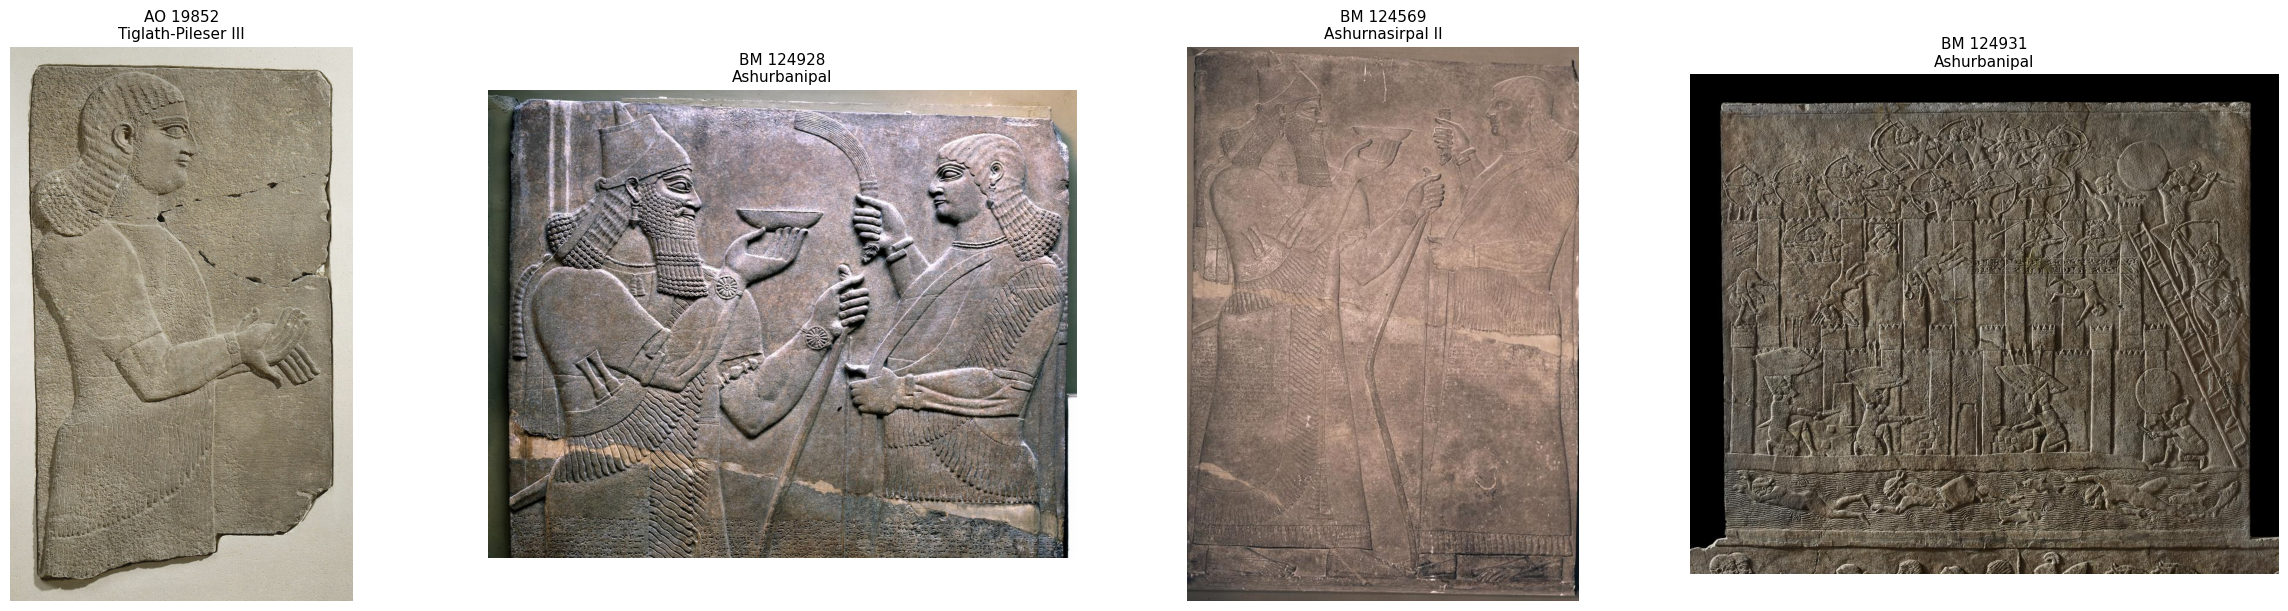

In [12]:
plot_query_and_retrieved_reliefs(
    image_level_csv=IMAGE_LEVEL_CSV,
    image_root=IMAGE_ROOT,
    query_relief_id=query_relief_id,
    retrieved_relief_ids=topk_reliefs[:3],   # first 3 retrieved neighbors
);

# show all views of the query relief

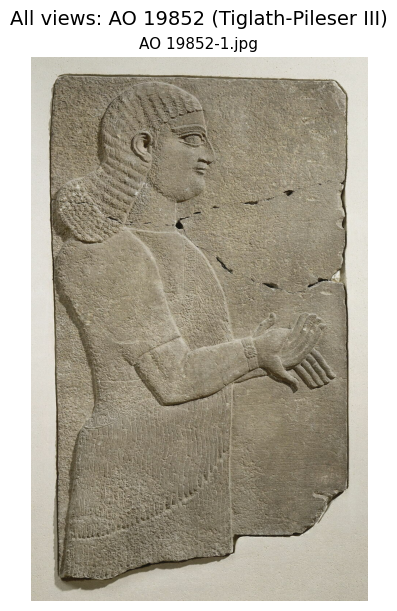

In [13]:
plot_relief_views(
    image_level_csv=IMAGE_LEVEL_CSV,
    image_root=IMAGE_ROOT,
    relief_id=query_relief_id,
    title=f"All views: {query_relief_id} ({query_authority})",
    show=True
);

# show all views of the top-1 retrieved relief

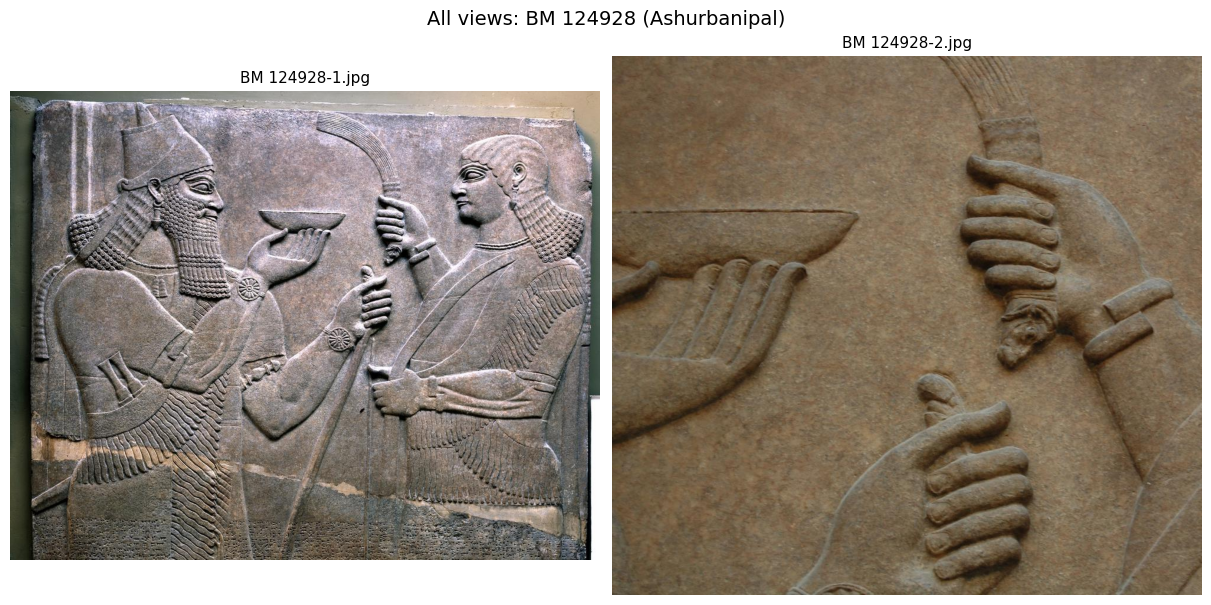

In [15]:
top1_relief_id = topk_reliefs[0]
top1_authority = topk_labels[0]

plot_relief_views(
    image_level_csv=IMAGE_LEVEL_CSV,
    image_root=IMAGE_ROOT,
    relief_id=top1_relief_id,
    title=f"All views: {top1_relief_id} ({top1_authority})",
);